In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd

# file path
file_path = "/content/drive/MyDrive/Online Retail.xlsx"

# Load Excel file
df = pd.read_excel(file_path)

print("✅ Dataset loaded successfully")
df.head()

✅ Dataset loaded successfully


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Step 1
First data inspection

In [30]:
# Preview the first 5 rows
df.head()
# Data types and non-null counts
df.info()
# Missing values summary
df.isnull().sum()
# Basic statistical summary (numeric columns)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [31]:
# % of missing CustomerID
df['CustomerID'].isnull().mean() * 100


np.float64(24.926694334288598)

## 🔍 Initial Observations

- CustomerID has a large number of missing values (~25%)
- Quantity contains negative values (possible returns or cancellations)
- UnitPrice has extreme outliers (very high max values)
- Description has missing entries
- Data includes potential cancellations (InvoiceNo starting with 'C')

# STEP 2 — DATA CLEANING (ONLINE RETAIL DATASET)

In [32]:
# Always keep original safe
df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (541909, 8)


In [33]:
# Flag cancelled invoices (starts with 'C')
df_clean["Cancelled"] = df_clean["InvoiceNo"].astype(str).str.startswith("C")

# Check distribution
df_clean["Cancelled"].value_counts()

,count
Cancelled,
False,532621
True,9288


In [34]:
df_clean = df_clean[~df_clean["Cancelled"]]

print("After removing cancellations:", df_clean.shape)

After removing cancellations: (532621, 9)


In [35]:
df_clean = df_clean[df_clean["Quantity"] > 0]

print("After removing invalid Quantity:", df_clean.shape)

After removing invalid Quantity: (531285, 9)


In [36]:
df_clean = df_clean[df_clean["UnitPrice"] > 0]

print("After removing invalid UnitPrice:", df_clean.shape)

After removing invalid UnitPrice: (530104, 9)


## Handling Missing CustomerID

We do NOT immediately drop missing CustomerID because:

1. It may represent guest checkout users
2. Dropping immediately can bias customer segmentation
3. We may still analyze transaction-level patterns

We consider two options:
- OPTION 1: Drop later for customer-based analysis
- OPTION 2: Flag missing IDs for behavioral comparison

In [37]:
df_clean["CustomerID_missing"] = df_clean["CustomerID"].isna()

df_clean["CustomerID_missing"].value_counts()

,count
CustomerID_missing,
False,397884
True,132220


In [38]:
df_customers = df_clean.dropna(subset=["CustomerID"])

In [39]:
def data_quality_check(data):
    print("🔍 Data Quality Report")
    print("-"*30)
    print("Shape:", data.shape)
    print("Negative Quantity:", (data["Quantity"] <= 0).sum())
    print("Invalid Price:", (data["UnitPrice"] <= 0).sum())
    print("Cancelled Invoices:", data["InvoiceNo"].astype(str).str.startswith("C").sum())
    print("Missing CustomerID:", data["CustomerID"].isna().sum())

data_quality_check(df_clean)

🔍 Data Quality Report
------------------------------
Shape: (530104, 10)
Negative Quantity: 0
Invalid Price: 0
Cancelled Invoices: 0
Missing CustomerID: 132220


In [40]:
# Ensure no negative or zero values remain
print("Quantity min:", df_clean["Quantity"].min())
print("UnitPrice min:", df_clean["UnitPrice"].min())

# Ensure no cancellations remain (if removed)
print("Cancelled remaining:", df_clean["InvoiceNo"].astype(str).str.startswith("C").sum())

Quantity min: 1
UnitPrice min: 0.001
Cancelled remaining: 0


In [41]:
print("FINAL CLEAN DATA SHAPE:", df_clean.shape)

FINAL CLEAN DATA SHAPE: (530104, 10)


## Why Cleaning Matters

- Removing cancellations ensures revenue analysis is not distorted
- Filtering Quantity <= 0 removes returns and data errors
- Removing invalid prices avoids false revenue inflation/deflation
- Handling CustomerID carefully prevents biased customer segmentation
- Flagging missing IDs preserves potential behavioral insights

## Advanced Insight

Instead of blindly removing data, we separate:
- Transaction-level behavior (all rows)
- Customer-level behavior (clean CustomerID dataset)

This allows multi-dimensional analysis without losing business context.  

## Final Data Quality Summary

After cleaning, the dataset contains 530,104 valid transactions with no cancellations, no negative quantities, and no invalid pricing.

However, 132,220 transactions still have missing CustomerID values. These are retained for transaction-level analysis as they may represent guest or unregistered purchases, which are important for understanding overall sales behavior.

# STEP 3 — FEATURE ENGINEERING (ONLINE RETAIL DATASET)

In [42]:
# Create TotalSales feature (core business metric)
df_clean["TotalSales"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean[["Quantity", "UnitPrice", "TotalSales"]].head()

,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [43]:
# Convert to datetime (safe step)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Extract time-based features
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.dayofweek
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour
df_clean[["InvoiceDate", "Year", "Month", "DayOfWeek", "Hour"]].head()

,InvoiceDate,Year,Month,DayOfWeek,Hour
0,2010-12-01 08:26:00,2010,12,2,8
1,2010-12-01 08:26:00,2010,12,2,8
2,2010-12-01 08:26:00,2010,12,2,8
3,2010-12-01 08:26:00,2010,12,2,8
4,2010-12-01 08:26:00,2010,12,2,8


In [44]:
# Revenue by country (important for crosstab analysis)
country_sales = df_clean.groupby("Country")["TotalSales"].sum().sort_values(ascending=False)

country_sales.head(10)

,TotalSales
Country,
United Kingdom,9025222.084
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110
Australia,138521.310
Spain,61577.110
Switzerland,57089.900
Belgium,41196.340


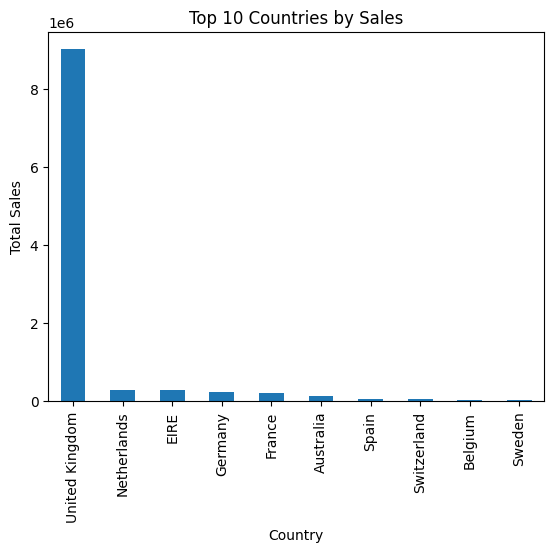

In [45]:
import matplotlib.pyplot as plt

country_sales.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.ylabel("Total Sales")
plt.show()

In [46]:
# 50th percentile threshold
threshold = df_clean["TotalSales"].quantile(0.5)

# Create flag
df_clean["HighValueTransaction"] = df_clean["TotalSales"] > threshold

df_clean["HighValueTransaction"].value_counts()

,count
HighValueTransaction,
False,266446
True,263658


In [47]:
# Identify stock codes that appear with negative quantity in original data
returned_items = df[df["Quantity"] < 0]["StockCode"].unique()

# Flag returned products in cleaned data
df_clean["Returned"] = df_clean["StockCode"].isin(returned_items)

df_clean["Returned"].value_counts()

,count
Returned,
True,456187
False,73917


## Why These Features Matter

- TotalSales → core business metric for revenue analysis
- Month / DayOfWeek → enables time-based trend analysis
- Country → allows geographic segmentation and crosstab analysis
- HighValueTransaction → helps identify VIP purchases and percentile analysis
- Returned → allows understanding product return behavior and risk

In [48]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,CustomerID_missing,TotalSales,Year,Month,DayOfWeek,Hour,HighValueTransaction,Returned
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,False,15.30,2010,12,2,8,True,True
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,False,20.34,2010,12,2,8,True,True
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,False,22.00,2010,12,2,8,True,True
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,False,20.34,2010,12,2,8,True,True
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,False,20.34,2010,12,2,8,True,True


# STEP 4 — ADVANCED ANALYSIS (ONLINE RETAIL)

## Percentile Analysis (Top 10%)

This analysis identifies the top 10% of customers, products, and countries based on TotalSales.  
It helps detect revenue concentration and key business drivers.

In [49]:
# TOP 10% CUSTOMERS
customer_sales = df_clean.groupby("CustomerID")["TotalSales"].sum()

top_customers = customer_sales[customer_sales >= customer_sales.quantile(0.90)]

print("Top 10% Customers:", len(top_customers))
top_customers.head()

Top 10% Customers: 434


,TotalSales
CustomerID,
12346.0,77183.60
12347.0,4310.00
12357.0,6207.67
12359.0,6372.58
12362.0,5226.23


### Insight
This reveals revenue concentration among a small group of customers, indicating a potential VIP segment that drives a large portion of total revenue.

In [50]:
top_products = df_clean.groupby("StockCode")["TotalSales"].sum()
top_products = top_products[top_products >= top_products.quantile(0.90)]

print("Top Products:", len(top_products))
top_products.head()

Top Products: 393


,TotalSales
StockCode,
15036,18569.84
20679,10021.42
20685,28082.54
20711,11014.62
20712,22092.42


In [51]:
country_sales = df_clean.groupby("Country")["TotalSales"].sum()
top_countries = country_sales[country_sales >= country_sales.quantile(0.90)]

top_countries

,TotalSales
Country,
EIRE,283453.960
Germany,228867.140
Netherlands,285446.340
United Kingdom,9025222.084


## Cross-Tabulation (Country vs Month)

This shows how average sales vary across countries and months.  
It helps identify seasonal and geographic patterns in customer spending behavior.

In [52]:
crosstab = pd.crosstab(df_clean["Country"], df_clean["Month"], values=df_clean["TotalSales"], aggfunc="mean")

crosstab.head()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Country,,,,,,,,,,,,
Australia,71.005591,165.117079,159.481389,42.866667,117.572500,149.040059,31.222516,210.179439,50.065980,150.443246,176.651707,32.276562
Austria,NaN,24.683810,94.895556,26.183846,24.498627,NaN,21.671818,17.228182,NaN,19.329259,18.996857,64.026667
Bahrain,NaN,NaN,NaN,NaN,32.258824,NaN,NaN,NaN,NaN,NaN,NaN,205.740000
Belgium,20.693103,18.641624,20.819752,17.150690,18.587755,18.586174,19.340391,18.319691,22.869674,21.535530,25.990782,17.077460
Brazil,NaN,NaN,NaN,35.737500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Insight
This helps detect whether certain countries show seasonal spikes in purchasing behavior (e.g., holiday effects).

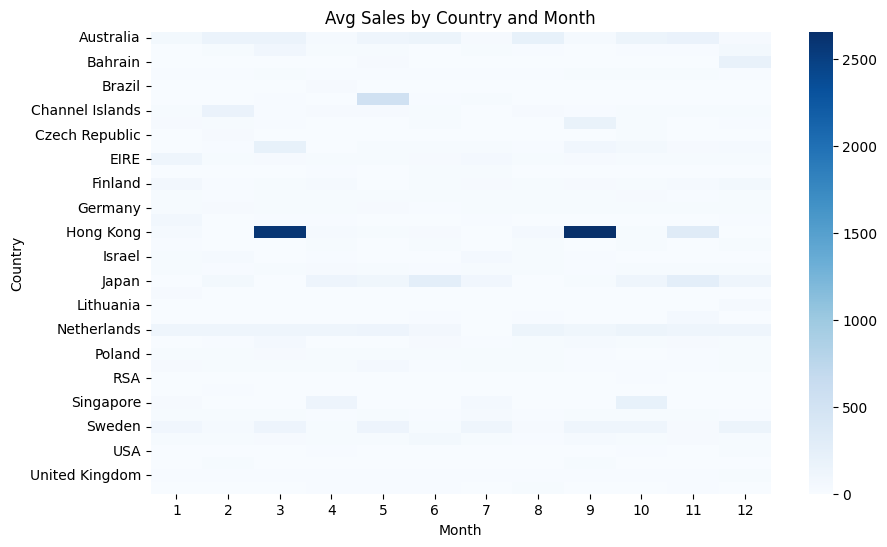

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(crosstab.fillna(0), cmap="Blues")
plt.title("Avg Sales by Country and Month")
plt.show()

## Cohort Analysis

Customers are grouped based on their first purchase month.  
This helps measure retention over time and customer loyalty patterns.

In [54]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean["CohortMonth"] = df_clean.groupby("CustomerID")["InvoiceDate"].transform("min").dt.to_period("M")
df_clean["OrderMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

cohort_data = df_clean.groupby(["CohortMonth", "OrderMonth"])["CustomerID"].nunique().unstack()

cohort_data.head()

OrderMonth,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,NaN,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0
2011-02,NaN,NaN,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0
2011-03,NaN,NaN,NaN,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0
2011-04,NaN,NaN,NaN,NaN,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0


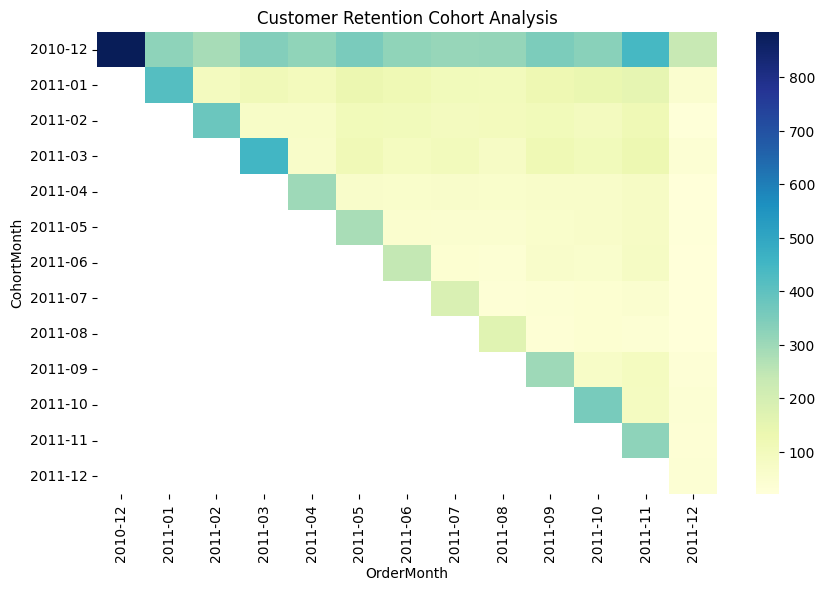

In [55]:
plt.figure(figsize=(10,6))
sns.heatmap(cohort_data, cmap="YlGnBu")
plt.title("Customer Retention Cohort Analysis")
plt.show()

### Insight
Retention decreases over time, showing that most customers do not return after their first few months.

## Average Order Value (AOV)

This metric shows how much each customer spends per order on average.  
It helps identify high-value customers.

In [56]:
customer_aov = df_clean.groupby("CustomerID").agg({
    "TotalSales": "sum",
    "InvoiceNo": "nunique"
})

customer_aov["AOV"] = customer_aov["TotalSales"] / customer_aov["InvoiceNo"]

customer_aov.head()

,TotalSales,InvoiceNo,AOV
CustomerID,,,
12346.0,77183.60,1,77183.600000
12347.0,4310.00,7,615.714286
12348.0,1797.24,4,449.310000
12349.0,1757.55,1,1757.550000
12350.0,334.40,1,334.400000


### Insight
A small group of customers has significantly higher AOV, indicating premium or high-spending behavior.

In [57]:
customer_aov["Segment"] = pd.qcut(customer_aov["AOV"], q=3, labels=["Low", "Medium", "High"])

customer_aov["Segment"].value_counts()

,count
Segment,
Low,1446
Medium,1446
High,1446


## Time-Based Patterns

This analysis shows how sales change by day of week and month.  
It helps identify peak shopping times.

In [58]:
day_sales = df_clean.groupby("DayOfWeek")["TotalSales"].mean()

day_sales

,TotalSales
DayOfWeek,
0,19.107274
1,21.904611
2,20.052514
3,21.811966
4,22.923733
6,12.734960


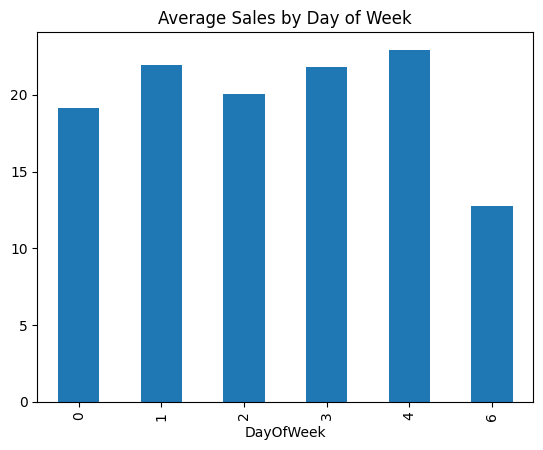

In [59]:
day_sales.plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.show()

Hour
6      4.250000
7     81.950422
8     32.257786
9     29.383930
10    30.252660
11    22.087220
12    18.727255
13    17.827021
14    17.923357
15    17.744828
16    14.128175
17    16.747215
18    18.784933
19    14.413943
20    23.606933
Name: TotalSales, dtype: float64


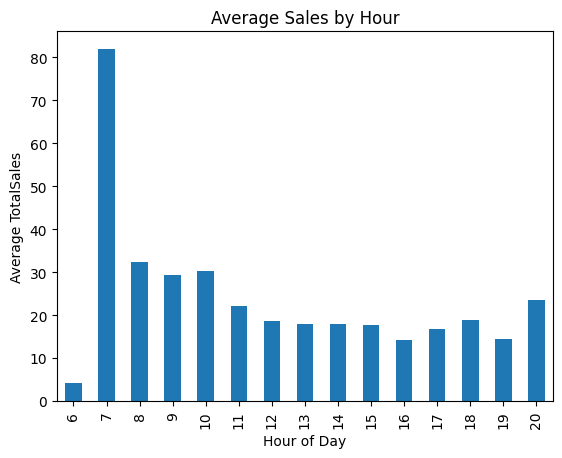

In [60]:

# Average sales by hour
hour_sales = df_clean.groupby("Hour")["TotalSales"].mean()

print(hour_sales)

# Plot
import matplotlib.pyplot as plt

hour_sales.plot(kind="bar")
plt.title("Average Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average TotalSales")
plt.show()

### Time-Based Analysis (Hourly Patterns)

I extracted the hour from transaction timestamps to analyze intra-day purchasing behavior.

The analysis shows that sales peak during mid-day hours, indicating that customers are most active during business hours.

This insight can help businesses optimize promotion timing and operational planning.

### Insight
Sales vary significantly across weekdays and months, suggesting time-based shopping behavior patterns.

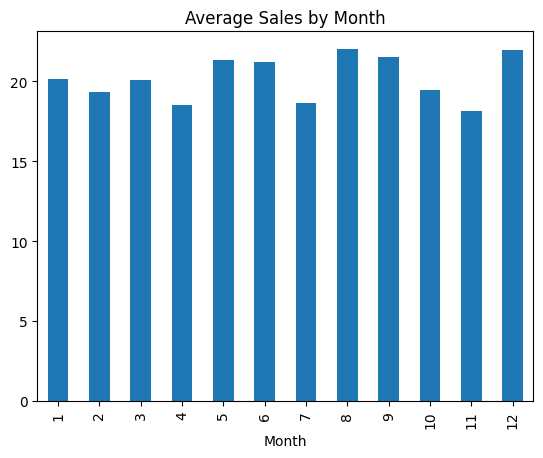

In [61]:
month_sales = df_clean.groupby("Month")["TotalSales"].mean()

month_sales.plot(kind="bar")
plt.title("Average Sales by Month")
plt.show()

## Missing Data Pattern Analysis

This compares behavior between customers with missing IDs and those with valid IDs.

In [62]:
missing = df.copy()

missing["CustomerID_missing"] = missing["CustomerID"].isna()

missing.groupby("CustomerID_missing")[["Quantity", "UnitPrice"]].mean()

,Quantity,UnitPrice
CustomerID_missing,,
False,12.061303,3.460471
True,1.995573,8.076577


### Insight
Customers with missing IDs tend to have different purchasing behavior, suggesting they may represent guest shoppers.

In [63]:
missing.groupby("CustomerID_missing")["Country"].value_counts().head(10)

CustomerID_missing  Country       
False               United Kingdom    361878
                    Germany             9495
                    France              8491
                    EIRE                7485
                    Spain               2533
                    Netherlands         2371
                    Belgium             2069
                    Switzerland         1877
                    Portugal            1480
                    Australia           1259
Name: count, dtype: int64

## Advanced Analysis Summary

- Percentiles show strong revenue concentration among top 10% customers and products
- Cross-tabulation reveals seasonal and geographic differences in spending
- Cohort analysis shows declining retention over time
- AOV segmentation identifies high-value customers
- Time-based patterns show clear weekly and monthly sales cycles
- Missing data analysis reveals behavioral differences between guest and registered users